# I. Numpy

### Импортируйте NumPy

In [149]:
import numpy as np

### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [150]:
import numpy as np

arr = np.zeros(10)
arr[4] = 1

arr_2d = arr.reshape(1, -1)

### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [151]:
arr = np.arange(10, 50)

reverse_arr = np.flip(arr)

even_nums = reverse_arr[reverse_arr % 2 == 0]


### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [152]:
arr_2d = np.random.randint(0, 9, size=(3, 3))


### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [153]:
arr_3d = np.random.rand(4, 3, 2)

min_value = np.min(arr_3d)
max_value = np.max(arr_3d)



### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [154]:
arr_x = np.random.rand(6, 4)
arr_y = np.random.rand(4, 3)

arr_z = arr_x @ arr_y

### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [155]:
import numpy as np

arr = np.random.rand(7, 7)

std = np.std(arr)

mean = np.mean(arr)
abs_mean = np.abs(arr - mean)
mad = np.mean(abs_mean)

arr_norm = (arr - mean) / mad

# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузите датасет Tips из набора датасетов seaborn

In [157]:
tips = sns.load_dataset("tips")

### Посмотрите на первые 5 строчек

In [158]:
print(tips.head(5))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### Узнайте сколько всего строчек и колонок в данных

In [159]:
print(tips.shape)

(244, 7)


### Проверьте есть ли пропуски в данных

In [160]:
nulls = tips.isnull().values.any() 

print(nulls)

False


** это отсылка с конца, очистим датасет от выбросов

In [161]:
cols = ['total_bill', 'tip']

Q1 = tips[cols].quantile(0.25)
Q3 = tips[cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((tips[cols] < (Q1 - 1.5 * IQR)) | (tips[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
data_tips = tips[mask].copy() # копи тут, потому что потом ругается, что не уверен, что изменения нормальные.




### Посмотрите на распределение числовых признаков

        total_bill         tip   sex smoker  day    time        size
count   229.000000  229.000000   229    229  229     229  229.000000
unique         NaN         NaN     2      2    4       2         NaN
top            NaN         NaN  Male     No  Sat  Dinner         NaN
freq           NaN         NaN   145    143   80     164         NaN
mean     18.476856    2.806332   NaN    NaN  NaN     NaN    2.484716
std       7.212792    1.085224   NaN    NaN  NaN     NaN    0.876588
min       3.070000    1.000000   NaN    NaN  NaN     NaN    1.000000
25%      13.130000    2.000000   NaN    NaN  NaN     NaN    2.000000
50%      17.260000    2.710000   NaN    NaN  NaN     NaN    2.000000
75%      22.670000    3.500000   NaN    NaN  NaN     NaN    3.000000
max      40.170000    5.850000   NaN    NaN  NaN     NaN    6.000000

total_bill    0.751805
tip           0.593934
size          1.525015
dtype: float64

total_bill    0.188249
tip          -0.263841
size          1.987823
dtype: float64



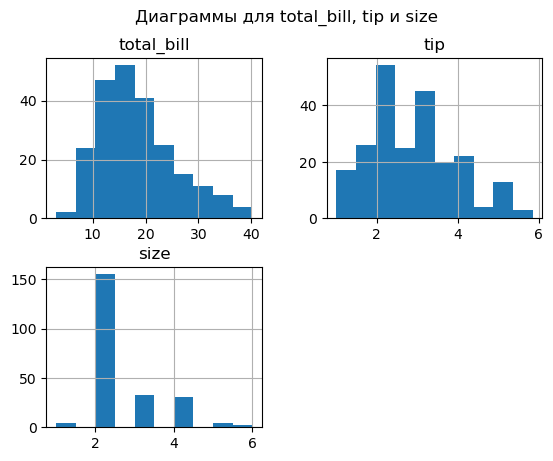

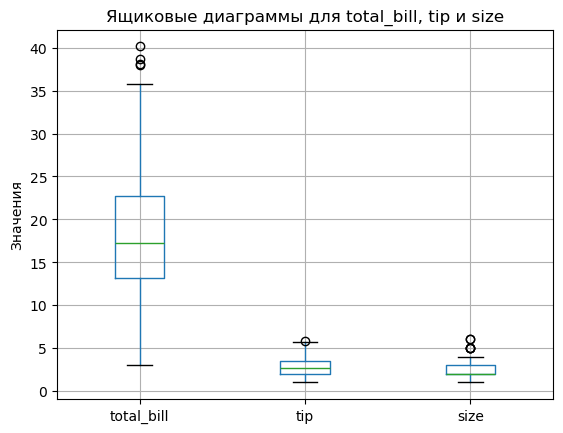

In [162]:
print(data_tips.describe(include = "all")) # (include = "all") - для всех столбцов.
print()
print(data_tips[['total_bill', 'tip', 'size']].skew()) #Скош
print()
print(data_tips[['total_bill', 'tip', 'size']].kurtosis()) #Эксцессы
print()
data_tips.hist() #Форма распределения
plt.suptitle('Диаграммы для total_bill, tip и size')
plt.show()
print()
data_tips.boxplot(column=['total_bill', 'tip', 'size'])
plt.title('Ящиковые диаграммы для total_bill, tip и size')
plt.ylabel('Значения')
plt.show()


### Найдите максимальное значение 'total_bill'

In [163]:
print(data_tips['total_bill'].max())

40.17


### Найдите количество курящих людей

In [164]:
print((data_tips['smoker'] == 'Yes').sum())

86


### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [165]:
print(data_tips.groupby('day')['total_bill'].mean())

day
Thur    16.571695
Fri     17.151579
Sat     18.625875
Sun     20.246761
Name: total_bill, dtype: float64


C:\Users\akalo\AppData\Local\Temp\ipykernel_17248\3311475477.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data_tips.groupby('day')['total_bill'].mean())


### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [166]:
tip_overmid = data_tips[data_tips['total_bill'] > data_tips['total_bill'].median()]
print(tip_overmid.groupby('sex', observed = True)['tip'].mean())
print('\n')
tip_overmid = data_tips[data_tips['total_bill'] <= data_tips['total_bill'].median()]
print(tip_overmid.groupby('sex', observed = True)['tip'].mean())

sex
Male      3.340123
Female    3.542727
Name: tip, dtype: float64


sex
Male      2.181094
Female    2.266667
Name: tip, dtype: float64


### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [167]:
data_tips['smoker'] = data_tips['smoker'].map({'Yes': True, 'No' : False})

# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

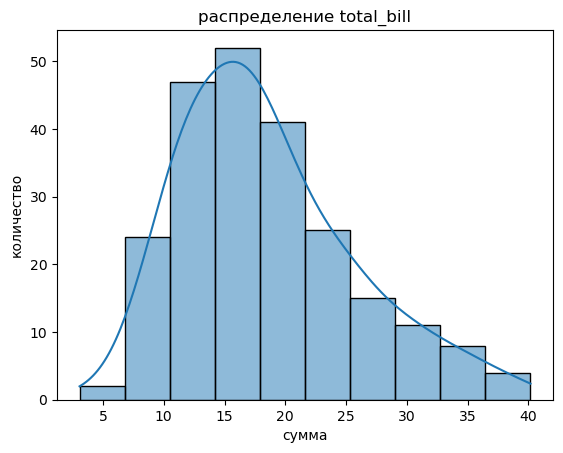

In [168]:
sns.histplot(data_tips['total_bill'], bins = 10, kde = True)

plt.title('распределение total_bill')
plt.xlabel('сумма')
plt.ylabel('количество')
plt.grid(False)

plt.show()



### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

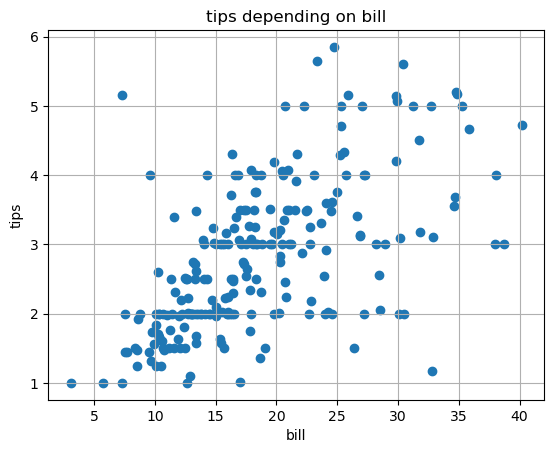

In [169]:
x = data_tips['total_bill']
y = data_tips['tip']

plt.scatter(x, y)

plt.title('tips depending on bill')
plt.xlabel('bill')
plt.ylabel('tips')
plt.grid(True)

plt.show()

### Постройте pairplot

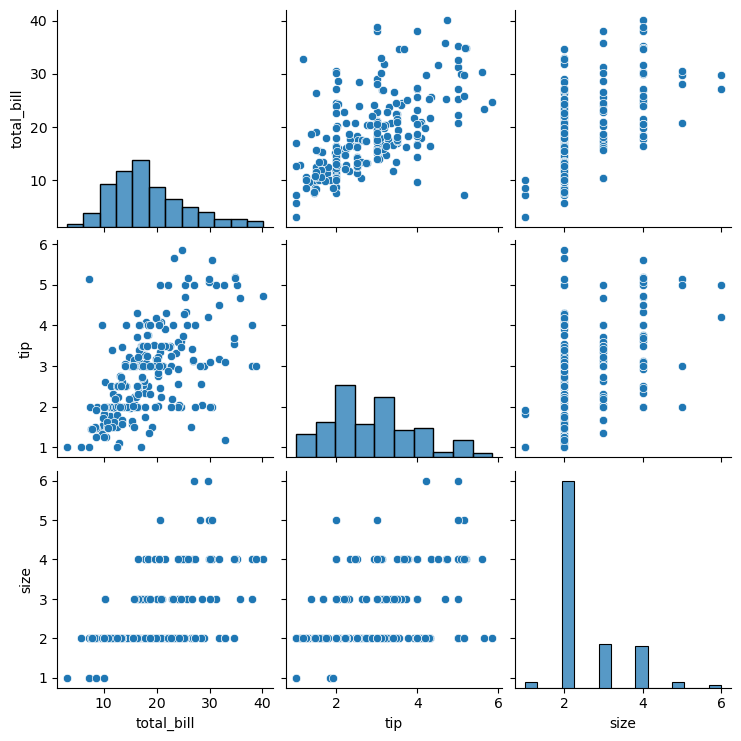

In [170]:
sns.pairplot(data_tips)
plt.show()

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

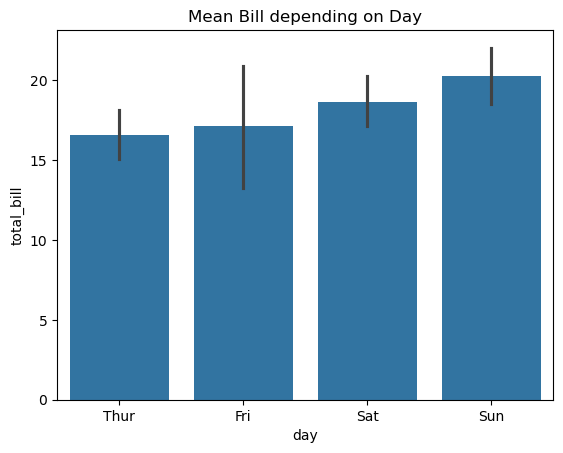

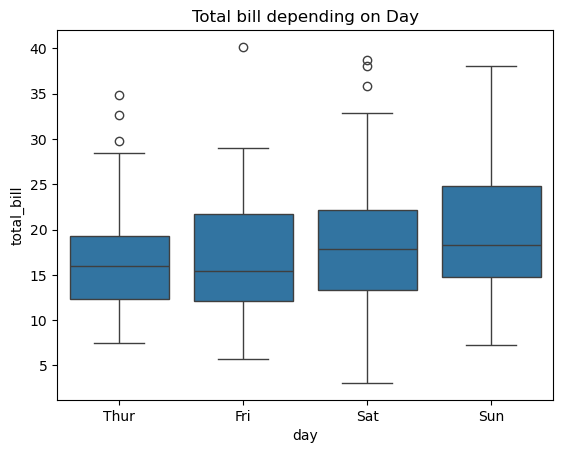

In [171]:
sns.barplot(x = 'day', y = 'total_bill', data = data_tips, estimator = 'mean')
plt.title('Mean Bill depending on Day')
plt.show()

sns.boxplot(x = 'day', y = 'total_bill', data = data_tips)

plt.title('Total bill depending on Day')
plt.show()



### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

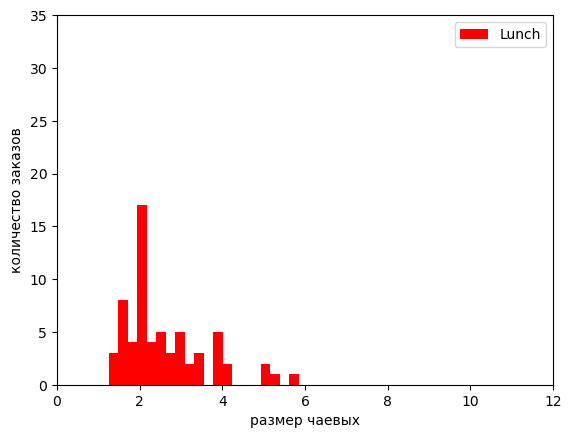

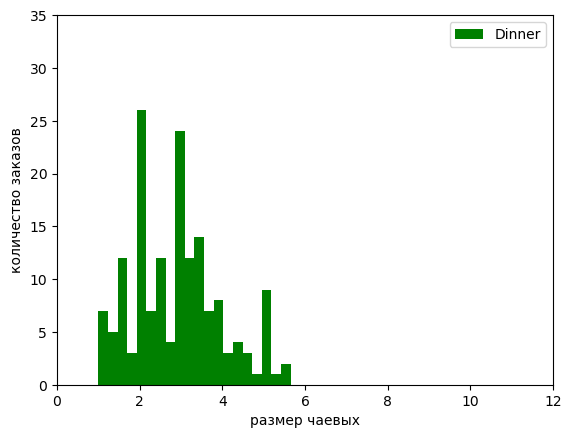

In [172]:
lunch_tips = data_tips[data_tips['time'] == 'Lunch']['tip']
plt.hist(lunch_tips, bins = 20, label = 'Lunch', color = 'red')
plt.legend()

plt.xlabel('размер чаевых')
plt.ylabel('количество заказов')
plt.xlim(0, 12)
plt.ylim(0, 35)

plt.show()

dinner_tips = data_tips[data_tips['time'] == 'Dinner']['tip']
plt.hist(dinner_tips, bins = 20, label = 'Dinner', color = 'green')
plt.legend()

plt.xlabel('размер чаевых')
plt.ylabel('количество заказов')
plt.xlim(0, 12)
plt.ylim(0, 35)
plt.show()

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

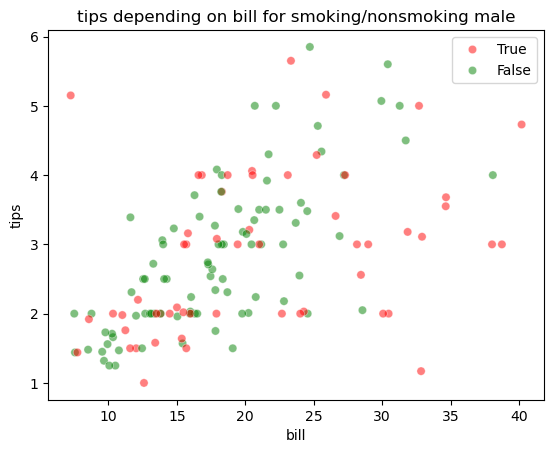

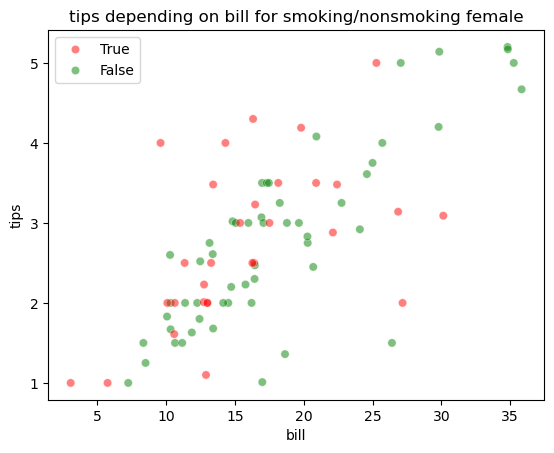

In [173]:
males = data_tips[data_tips['sex'] == 'Male']
x = data_tips['total_bill']
y = data_tips['tip']

sns.scatterplot(data = males, x = 'total_bill', y = 'tip', hue = 'smoker', palette = {True: 'red', False : 'green'}, alpha=0.5)

plt.legend()
plt.title('tips depending on bill for smoking/nonsmoking male')
plt.xlabel('bill')
plt.ylabel('tips')

plt.show()


females = data_tips[data_tips['sex'] == 'Female']
x = data_tips['total_bill']
y = data_tips['tip']

sns.scatterplot(data = females, x = 'total_bill', y = 'tip', hue = 'smoker', palette = {True: 'red', False : 'green'}, alpha=0.5)

plt.legend()
plt.title('tips depending on bill for smoking/nonsmoking female')
plt.xlabel('bill')
plt.ylabel('tips')


plt.show()


## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

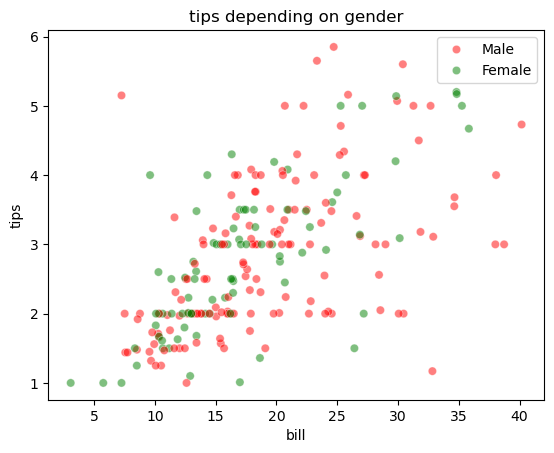

In [174]:
x = data_tips['total_bill']
y = data_tips['tip']

sns.scatterplot(data = data_tips, x = 'total_bill', y = 'tip', hue = 'sex', palette = {'Male': 'red', 'Female': 'green'}, alpha=0.5)

plt.legend()
plt.title('tips depending on gender')
plt.xlabel('bill')
plt.ylabel('tips')

plt.show()

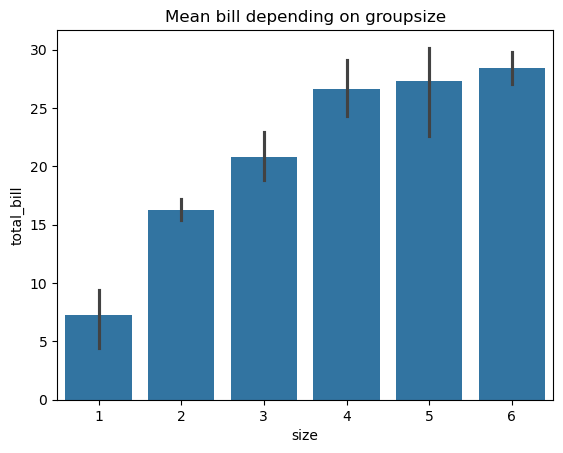

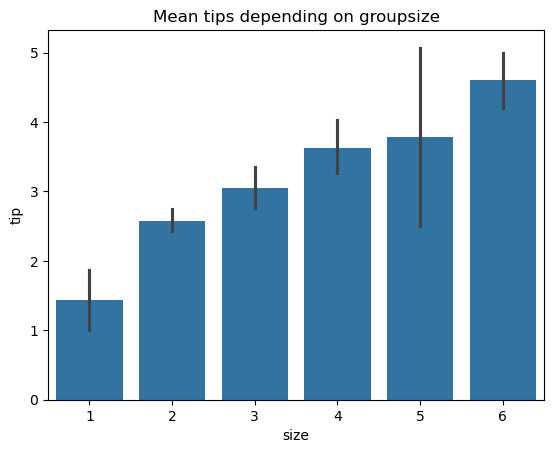

In [175]:
sns.barplot(x = 'size', y = 'total_bill', data = data_tips, estimator = 'mean')
plt.title('Mean bill depending on groupsize')
plt.show()

sns.barplot(x = 'size', y = 'tip', data = data_tips, estimator = 'mean')
plt.title('Mean tips depending on groupsize')
plt.show()

Средний счет и средние чаевые на человека в зависимости от размера группы

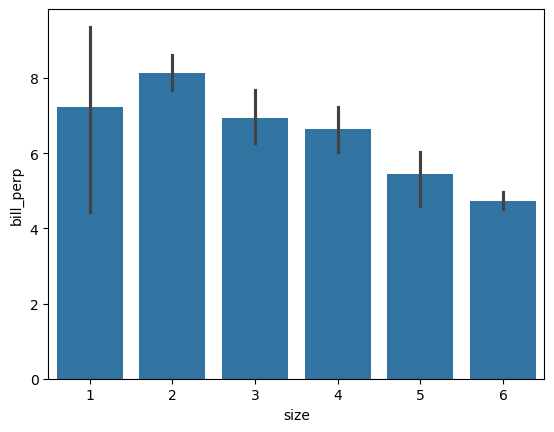

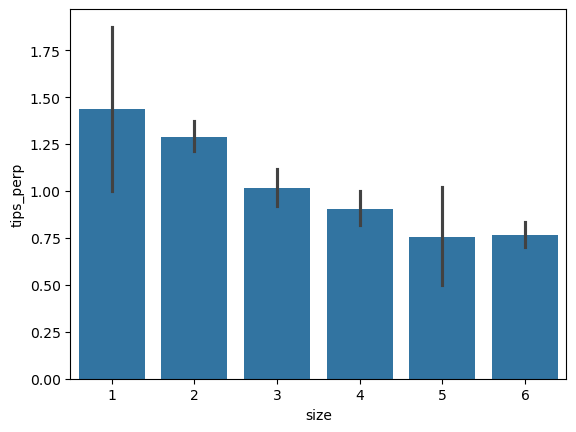

In [176]:
data_tips['bill_perp'] = data_tips['total_bill'] / data_tips['size']
data_tips['tips_perp'] = data_tips['tip'] / data_tips['size']

mean_bill = data_tips.groupby('size')[['bill_perp']].mean()
mean_tips = data_tips.groupby('size')[['tips_perp']].mean()

sns.barplot(data = data_tips, x = 'size', y = 'bill_perp')
plt.show()

sns.barplot(data = data_tips, x = 'size', y = 'tips_perp')
plt.show()

Где бизнес?

In [177]:
mean_bill_all = data_tips['bill_perp'].mean()
mean_tips_all = data_tips['tips_perp'].mean()

grouped = data_tips.groupby(['sex', 'smoker', 'size'])[['bill_perp', 'tips_perp']].mean()

grouped['bill_profit'] = grouped['bill_perp'] - mean_bill_all
grouped['tips_profit'] = grouped['tips_perp'] - mean_tips_all

top_bill = grouped[['bill_profit']].sort_values(by = 'bill_profit', ascending = False).head(6).reset_index()
top_tips = grouped[['tips_profit']].sort_values(by = 'tips_profit', ascending = False).head(6).reset_index()

print(f'средний счет по всем - {mean_bill_all}, средний чай по всем - {mean_tips_all}')
print()
print(top_bill)
print()
print(top_tips)


средний счет по всем - 7.6764556040756915, средний чай по всем - 1.1868471615720524

      sex smoker  size  bill_profit
0    Male   True     2     1.768169
1  Female  False     1     0.983544
2    Male   True     1     0.903544
3  Female   True     2     0.102744
4    Male  False     2     0.043544
5    Male   True     3    -0.066456

      sex smoker  size  tips_profit
0    Male   True     1     0.733153
1  Female  False     1     0.228153
2  Female   True     2     0.181553
3    Male   True     2     0.155778
4    Male  False     2     0.091925
5  Female  False     2    -0.001544


C:\Users\akalo\AppData\Local\Temp\ipykernel_17248\3099913843.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_tips.groupby(['sex', 'smoker', 'size'])[['bill_perp', 'tips_perp']].mean()


Выводы:

Большинство заказов — в пределах $10–30. В этом диапазоне чаевые составляют ~15% и растут вместе со счётом. Далее рост чаевых замедляется, а зависимость становится неочевидной. Возможно, при высоких чеках люди выходят за бюджет или не являются постоянными клиентами.

Заведение чаще выбирают для ужина. Средний счёт растёт с четверга по воскресенье.

Курящие мужчины оставляют меньше чаевых, чем некурящие. 
Курящие женщины — больше. 
Женщины независимо от курения оставляют больше чаевых, чем мужчины.

Сумма чека растёт с числом гостей, но в пересчёте на одного человека — компании из 5–6 человек тратят меньше.

Для кого работает заведение:
Больше всего прибыли приносят курящие гости, пришедшие в одиночку или вдвоём, Ощутимого гендерного перекоса нет. Чаевые от них — выше среднего. 
